# Numerically solving the Schrodinger equation

In this assignment you will use [<tt>qmsolve</tt>](https://github.com/quantum-visualizations/qmsolve) to solve the time-independent Schrodinger equation in one dimension and plot the solutions.

### First, install <tt>qmsolve</tt> in one of two ways:
<ul>
    <li>From a <tt>unix</tt> command line, type <tt>pip install qmsolve</tt></li>
    <li>Put the following commands in a code cell in this notebook and execute:<br />
        <tt>import sys</tt><br />
        <tt>!{sys.executable} -m pip install qmsolve</tt></li>
</ul>

### Homework problems:

<ol start=0>
    <li>Follow the link to the <tt>qmsolve</tt> GitHub page above. Click the link for the <tt>examples</tt> folder, then click on the <tt>eigenstate solver examples</tt> folder. Finally, click on <tt>1D_harmonic_oscillator.py</tt> to see a short code snippet that will calculate wavefunctions for a simple harmonic oscillator (SHO).</li>
    <li><tt>1D_harmonic_oscillator.py</tt> imports the <tt>Hamiltonian</tt> class from <tt>qmsolve</tt>. In quantum mechanics, what is a Hamiltonian? Please use multiple sources to formulate your answer and cite those sources. For this problem, crowd-sourced references such as Wikipedia and stackexchange are acceptable.</li>
    <li>Which force law is defined in the function <tt>harmonic_oscillator()</tt> in cell 2 of this notebook?</li>
    <li>What are the eigenstates referred to in lines 22 and 23 in <tt>1D_harmonic_oscillator.py</tt>? Again, please use multiple sources to formulate your answer and cite those sources.
    <li>Code cells 1 and 2 below contain imported code from <tt>1D_harmonic_oscillator.py</tt>, including a visualization of eigenstate 0 of the SHO. In subsequent code cells, plot any five SHO eigenstates of your choice.</li>
</ol>

Note: you can write your answers to the non-code problems in a markdown cell. From within a new notebook cell, click the box with the downward-pointing arrow that says "Code" (on your Jupyter toolbar) and change to "Markdown". Then you can just type in the cell like a regular text file.

In [6]:
import sys
!{sys.executable} -m pip install qmsolve

1. A Hamiltonian is an operator corresponding to the total energy of that system, including both kinetic energy and potential energy. Its spectrum, the system's energy spectrum or its set of energy eigenvalues, is the set of possible outcomes obtainable from a measurement of the system's total energy. Due to its close relation to the energy spectrum and time-evolution of a system, it is of fundamental importance in most formulations of quantum theory [(Wikipedia)](https://en.wikipedia.org/wiki/Hamiltonian_(quantum_mechanics)). A Hamiltonian will also contain information about the possible paths that the system can follow [(Stackexchange)](https://math.stackexchange.com/questions/2040562/what-is-exactly-a-hamiltonian-or-lagrangian).
2. Hooke's law is defined in the function harmonic_oscillator() in cell 2 of this notebook
3. The eigenstates are referred to as the allowed quantum wavefunctions of the harmonic oscillator that satisfy the time-independent Schrödinger equation [(Wikipedia,](https://en.wikipedia.org/wiki/Quantum_harmonic_oscillator)[ GitHub)]( https://github.com/quantum-visualizations/qmsolve/blob/main/examples/eigenstate%20solver%20examples/1D_harmonic_oscillator.py)

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from qmsolve import Hamiltonian, SingleParticle, init_visualization, Å, eV

Computing...
Took 0.039705753326416016
[ 13.8243627   41.46350403  69.08346722  96.68423227 124.26577906
 151.82808744 179.37113718 206.89490796 234.39937942 261.8845311
 289.35034249 316.79679298 344.22386192 371.63152856 399.01977209
 426.38857162 453.73790619 481.06775475 508.3780962  535.66890934
 562.9401729  590.19186555 617.42396585 644.63645231 671.82930335
 699.00249732 726.15601246 753.28982697 780.40391895 807.49826642]


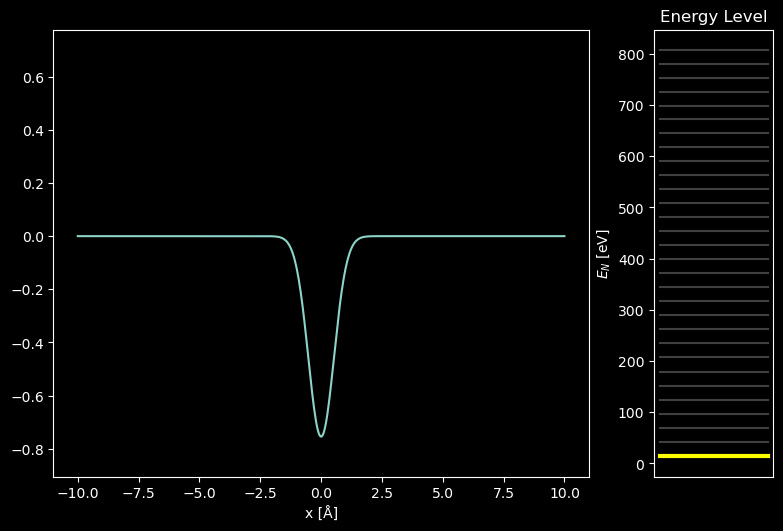

In [9]:
# Harmonic oscillator potential
def harmonic_oscillator(particle):
    k = 100 * eV / Å**2
    return 0.5 * k * particle.x**2

# Define the Hamiltonian
H = Hamiltonian(particles = SingleParticle(), potential = harmonic_oscillator, 
                spatial_ndim = 1, N = 512, extent = 20*Å)

#Diagonalize the Hamiltonian and compute the eigenstates
eigenstates = H.solve(max_states = 30)

# Print out the energies of the eigenstates
print(eigenstates.energies) # the printed energies are expressed in eV

# Visualize the Eigenstates
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(0)

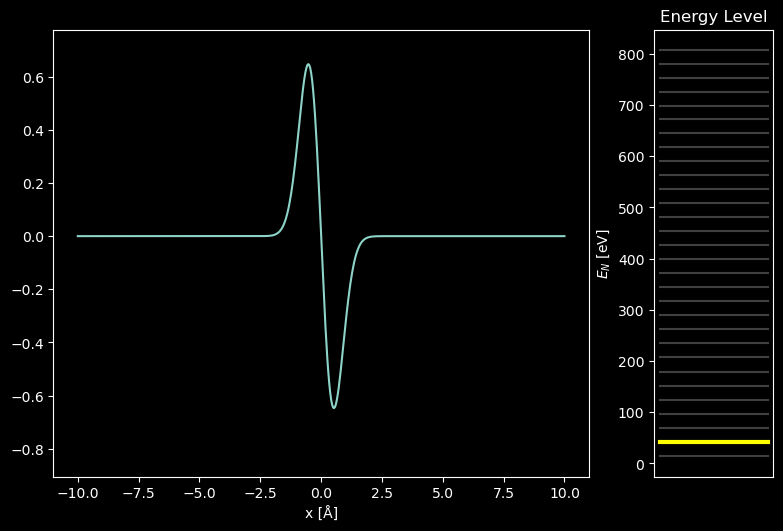

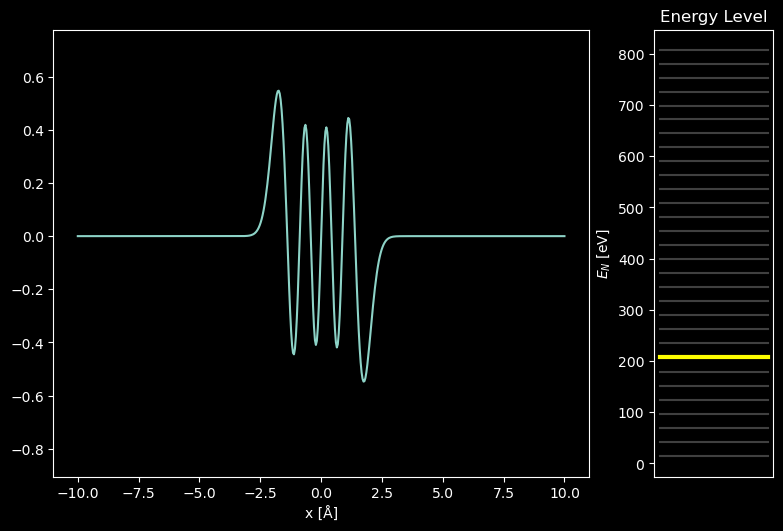

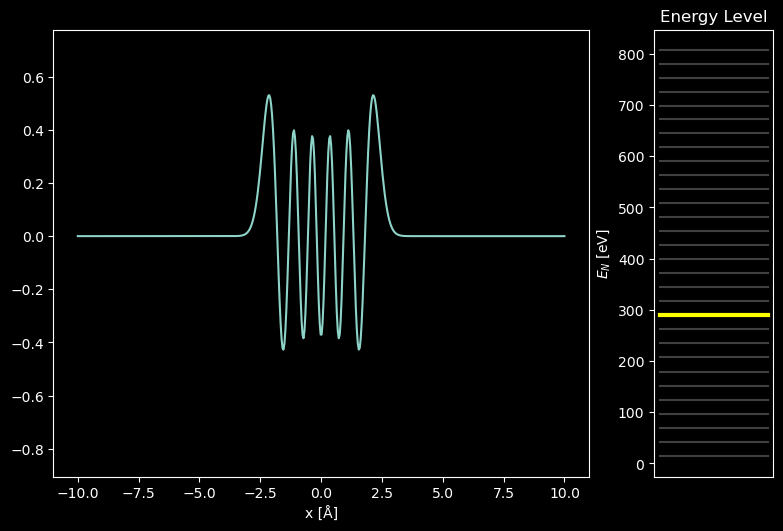

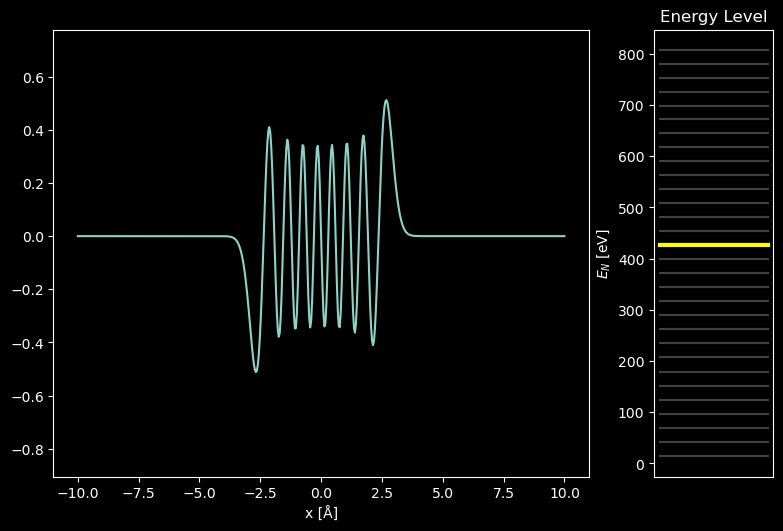

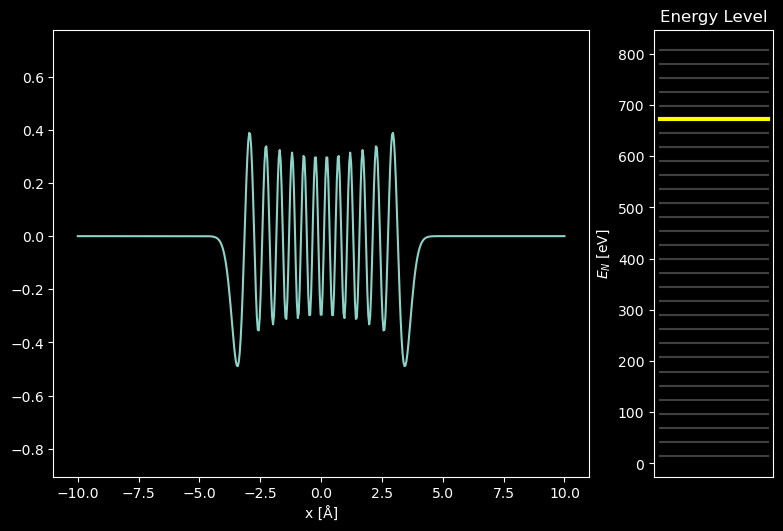

In [11]:
#Question 4: Plotting five eigenstates of the harmonic oscillator
visualization.plot_eigenstate(1)
visualization.plot_eigenstate(7)
visualization.plot_eigenstate(10)
visualization.plot_eigenstate(15)
visualization.plot_eigenstate(24)

<ol start=5>
    <li>What is on the x-axis of your plots?</li>
    <li>Are your plots showing wave functions $\psi(x)$ or probability functions $\psi^*(x) \psi(x)$? How do you know?</li>
</ol>

5 (Answer): The position of the particle (in Ångstoms) in the simple harmonic oscillator is on the x-axis of my plots.

6 (Answer): The plots are showing the wave functions $\psi(x)$, not the probability functions $\psi^*(x) \psi(x)$. 
I know this because the function visualization.plot_eigenstate() is plotting the eigenstates directly. 
In addition to that, the graphs include positive and negative values. The probability function can never be negative because in the context of probability, they must always either be zero or positive.

### New potential: infinite square well

Below I define the infinite square well potential for $L = 8$ Angstroms and plot the two lowest-energy eigenstates (compare to Figure 6.3 in your textbook).

Computing...
Took 0.0676889419555664
[  0.58926935   2.35704264   5.30321556   9.4276143   14.7299955
  21.21004635  28.8673845   37.70155819  47.71204619  58.89825789
  71.2595333   84.79514311  99.50428872 115.3861023  132.43964681
 150.6639161  170.05783494 190.6202591  212.34997539 235.24570176
 259.30608737 284.52971266 310.91508944 338.46066097 367.16480207
 397.0258192  428.04195057 460.21136622 493.53216816 528.00239048]


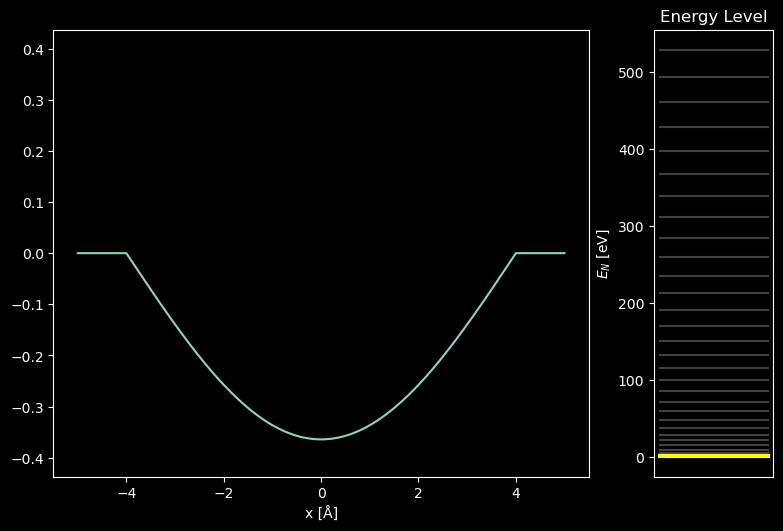

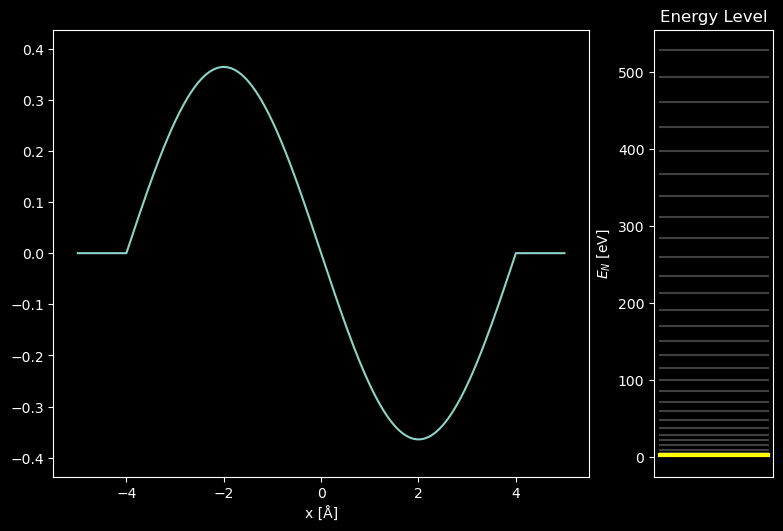

In [13]:
# 8 angstrom-wide infinite square well
def infinite_square_well(particle):
    potential = np.zeros_like(particle.x)
    out_of_bounds = np.abs(particle.x) > 4*Å
    potential[out_of_bounds] = np.inf
    return potential

# Define the Hamiltonian of the infinite square well
H_sw = Hamiltonian(particles = SingleParticle(), potential = infinite_square_well, 
                   spatial_ndim = 1, N = 512, extent = 10*Å)

# Diagonalize the Hamiltonian and compute the eigenstates
eigenstates_sw = H_sw.solve(max_states = 30)

print(eigenstates_sw.energies)

# Visualize the infinite square well eigenstates
visualization_sw = init_visualization(eigenstates_sw)
visualization_sw.plot_eigenstate(0)
visualization_sw.plot_eigenstate(1)

<ol start=7>
    <li>Plot any three infinite square well eigenstates of your choice.</li>
    <li>What property do the infinite square well eigenstates have that's different than the SHO eigenstates? (Hint: think about the properties of valid wave functions we discussed in class)</li>
    <li>What is the relationship between the number of extrema (maxima plus minima) in each eigenstate plot and the quantum number of the eigenstate?</li>
</ol>

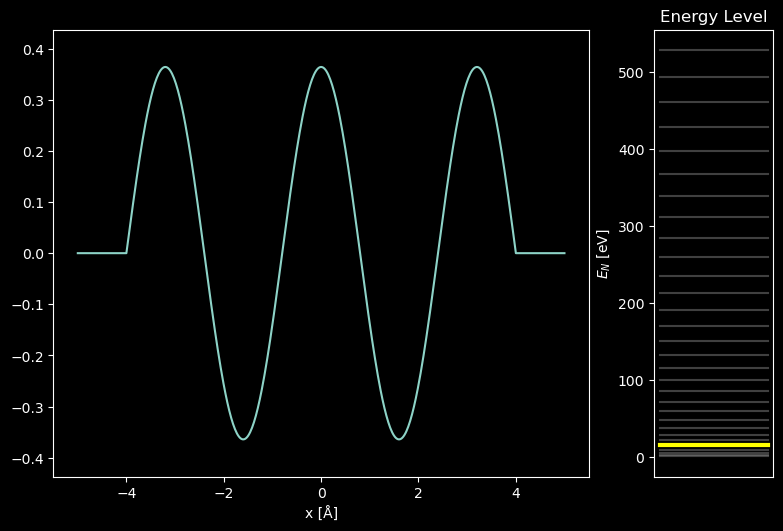

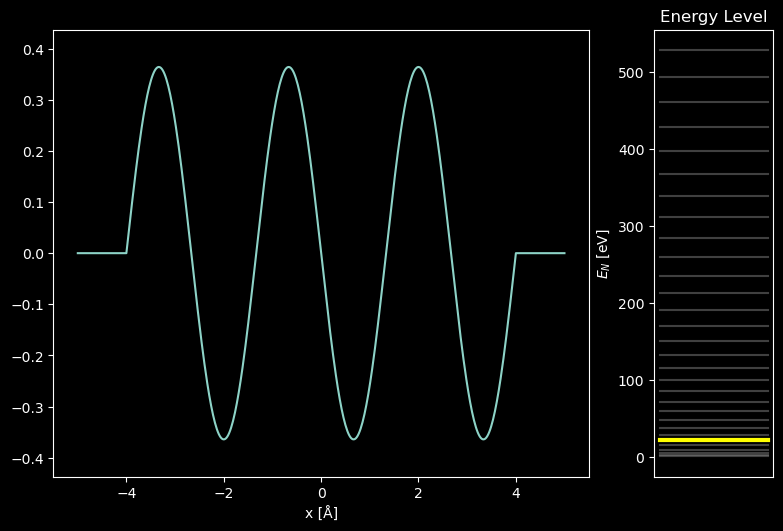

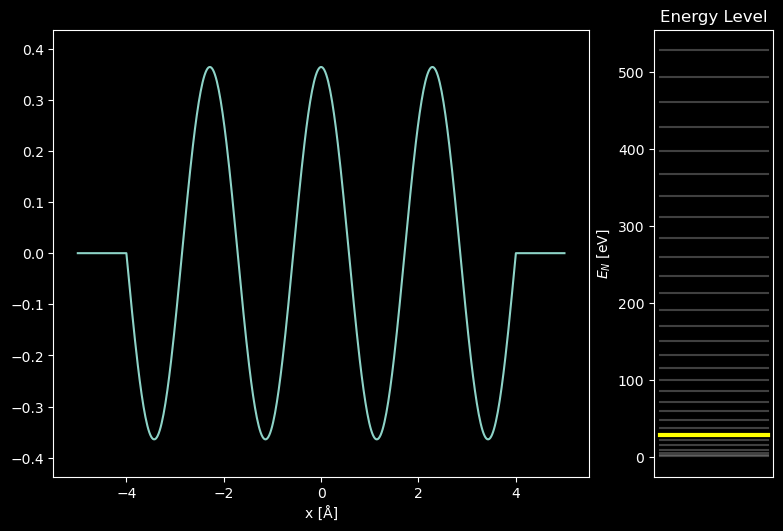

In [14]:
#Question 7
visualization_sw.plot_eigenstate(4)
visualization_sw.plot_eigenstate(5)
visualization_sw.plot_eigenstate(6)

8. The property that the infinite square well eigenstates have that's different than the SHO eigenstates is that the infinite square well eigenstates are exactly zero at the boundaries of the well, while the SHO eigenstates extend outward and only approach zero gradually. This happens because the infinite square well has infinitely high walls, so the wave function must be zero outside the box and at the edges. 
9. The relationship between the number of extrema (maxima plus minima) in each eigenstate plot and the quantum number of the eigenstates the quantum number is when n increases, the number of extrema also increases. For the nth eigenstate, there are
n + 1 extrema. 

### Now it's your turn to define a potential

<ol start=10>
    <li>Write a function that defines a <em>finite square-well</em> potential (textbook section 5.4). You can choose the width of the well in Angstroms and the potential at the walls in eV. Calculate the finite square-well Hamiltonian and plot any five eigenstates you choose.</li>
    <li>Based on your plots, do you think a particle can get out of the finite square-well potential no matter its quantum number $n$?</li>
</ol>

Computing...
Took 0.0044748783111572266


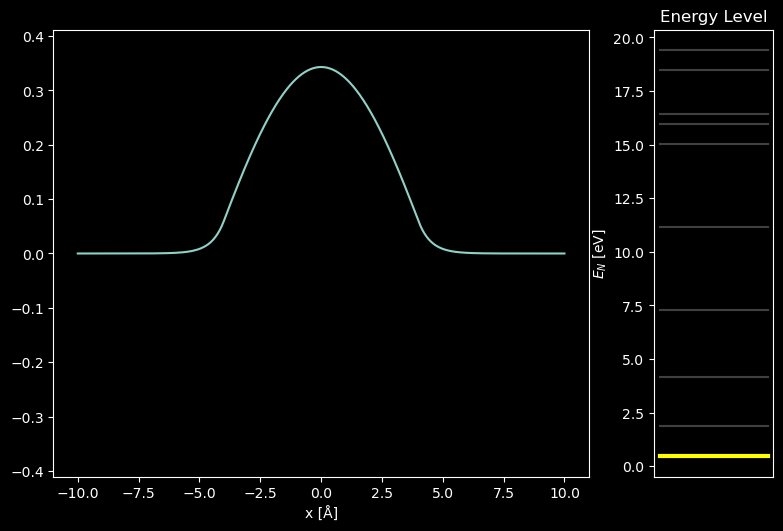

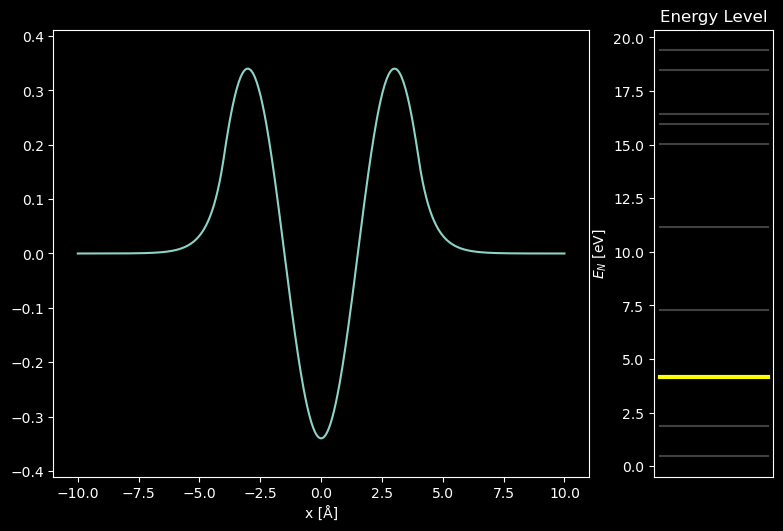

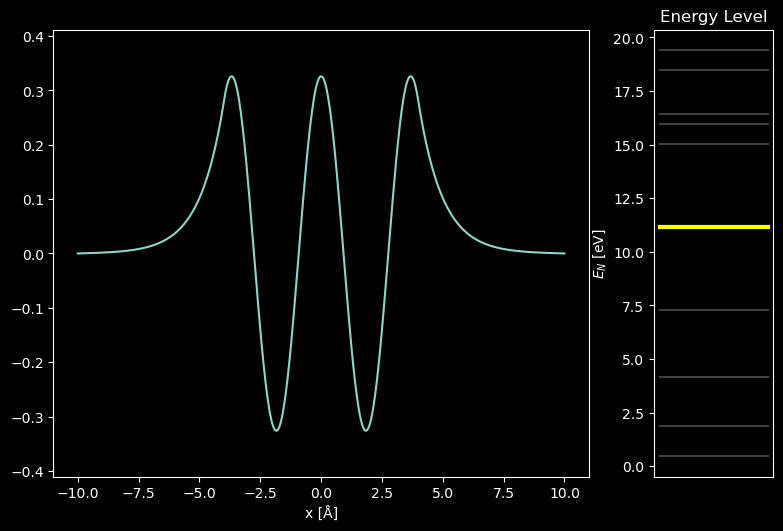

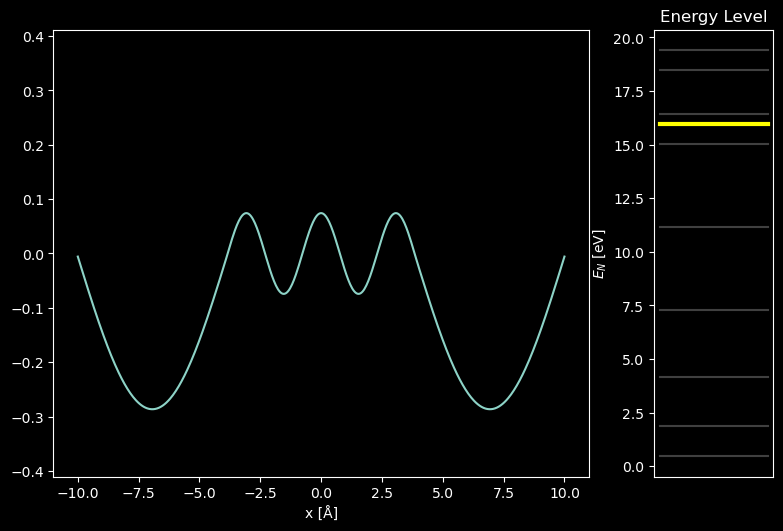

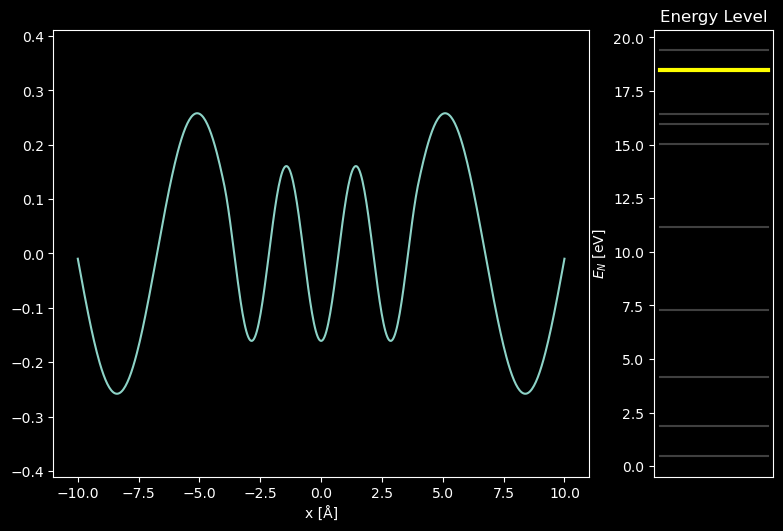

In [21]:
#Question 10
def finite_square_well(particle):

    #Width of the well
    width = 4*Å

    #Potential outside the well
    V_0 = 15*eV

    #Define the potential
    return np.where(abs(particle.x) < width, 0, V_0)


#Hamiltonian defintion of finite square well
H_finiteSW = Hamiltonian(particles = SingleParticle(),potential = finite_square_well,
                         spatial_ndim = 1,N = 512,extent = 20*Å)

#Solving for eigenstates
finite_eigenstates = H_finiteSW.solve(max_states = 10)

#Visualizing eigenstates
finite_visualization = init_visualization(finite_eigenstates)

finite_visualization.plot_eigenstate(0)
finite_visualization.plot_eigenstate(2)
finite_visualization.plot_eigenstate(4)
finite_visualization.plot_eigenstate(6)
finite_visualization.plot_eigenstate(8)

11. Based on the plots, I think that a particle can sometimes escape the finite square-well potential depending on its quantum number. Unlike the infinite square well, the walls of the finite well are not infinitely high, so the wave functions extend slightly outside the well. This means there is a nonzero probability of finding the particle outside the well due to quantum tunneling.